In [1]:
import copy
import os

import numpy as np
import torch
import torch.nn as nn
import math

from torch.func import jacrev

# Enable the system LaTeX engine
import matplotlib.pyplot as plt
import matplotlib as mpl

# Enable the system LaTeX engine
mpl.rcParams['text.usetex'] = True

TRAIN = False

In [2]:
# ============================================================
# Device selection
# Priority: CUDA -> MPS -> CPU
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [3]:
import glob

# ============================================================
# Circle dataset
# ============================================================

def sample_circle(n, device=device):
    theta = 2 * np.pi * torch.rand(n, device=device)

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=-1,
    )

    return z


def sample_xt(n, device=device):
    z = sample_circle(n, device)

    eps = torch.randn_like(z)

    t = torch.rand(n, 1, device=device)

    x = t * z + (1 - t) * eps

    target_velocity = z - eps

    return x, t, target_velocity


# ============================================================
# Flow matching network
# ============================================================

class FMNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=-1)
        return self.net(inp)


# ============================================================
# Training with checkpoints + sample plots every 5k steps
# ============================================================

CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

def _plot_samples(net, step, device, nsamples=512, T=0.999, nsteps=200):
    net.eval()
    with torch.no_grad():
        x = torch.randn(nsamples, 2, device=device)
        dt = T / nsteps
        s = 0.0
        for _ in range(nsteps):
            tt = torch.full((x.shape[0], 1), s, device=device)
            x = x + dt * net(x, tt)
            s += dt
        pts = x.cpu().numpy()
    net.train()

    theta_c = np.linspace(0, 2 * np.pi, 300)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot(np.cos(theta_c), np.sin(theta_c), "k--", linewidth=1, label="unit circle")
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5, label="samples")
    ax.set_aspect("equal")
    ax.set_title(f"step {step:,}")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def train_checkpoints(
    net,
    total_steps=50000,
    checkpoint_interval=5000,
    batch_size=4096,
    lr=1e-4,
):
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)

    checkpoints = {}

    for step in range(total_steps + 1):

        if step % checkpoint_interval == 0 and step > 0:
            state = copy.deepcopy(net.state_dict())
            checkpoints[step] = state
            torch.save(state, os.path.join(CKPT_DIR, f"step_{step:06d}.pt"))
            print(f"step={step:6d}  loss={loss.item():.6f}  lr={scheduler.get_last_lr()[0]:.2e}")
            _plot_samples(net, step, device)

        if step == total_steps:
            break

        x, t, v = sample_xt(batch_size, device=device)

        pred = net(x, t)
        loss = (pred - v).pow(2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()

    return checkpoints


net = FMNet().to(device)

if TRAIN:
    checkpoints = train_checkpoints(net)
else:
    checkpoints = {}
    for f in sorted(glob.glob(os.path.join(CKPT_DIR, "step_*.pt"))):
        step = int(os.path.basename(f).split("_")[1].split(".")[0])
        checkpoints[step] = torch.load(f, map_location=device)
    if checkpoints:
        net.load_state_dict(checkpoints[max(checkpoints)])
        print(f"TRAIN=False — loaded {len(checkpoints)} checkpoints from disk, latest step={max(checkpoints)}")
    else:
        print("TRAIN=False but no checkpoints found on disk — set TRAIN=True to train.")


TRAIN=False — loaded 10 checkpoints from disk, latest step=50000


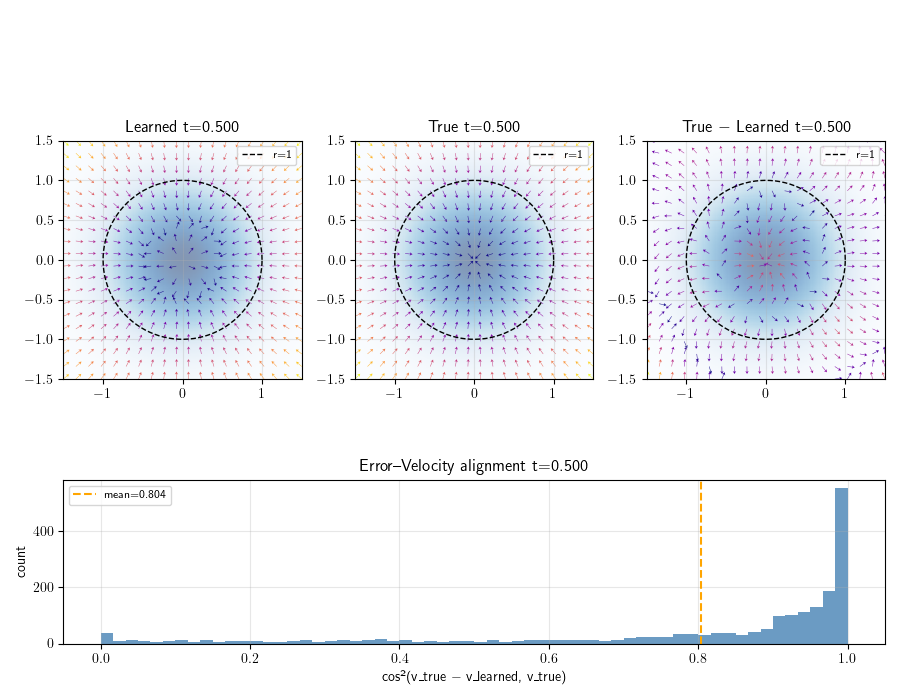

In [4]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox
from scipy.special import ive
from scipy.optimize import brentq


def _density_pt(Gx, Gy, t_val):
    r = np.sqrt(Gx**2 + Gy**2)
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r / s**2
    log_p = np.log(ive(0, kappa) + 1e-300) + kappa - (r**2 + t_val**2) / (2 * s**2)
    p = np.exp(log_p - log_p.max())
    return p


def _zero_true_velocity_radius(t_val, r_min=1e-3, r_max=50.0):
    if t_val <= 0:
        return None
    s = max(1 - t_val, 1e-6)
    def f(r):
        kappa = t_val * r / s**2
        A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
        return A - r
    rs = np.geomspace(r_min, r_max, 500)
    fs = np.array([f(r) for r in rs])
    signs = np.sign(fs)
    idx = np.where(np.diff(signs) != 0)[0]
    if len(idx) == 0:
        return None
    return brentq(f, rs[idx[0]], rs[idx[0] + 1], xtol=1e-6)


def _score_pt(pts_np, t_val):
    """∇ log p_t(x) = (t·A(κ) − r) / s² · x̂"""
    x1, x2 = pts_np[:, 0], pts_np[:, 1]
    r = np.sqrt(x1**2 + x2**2) + 1e-12
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r / s**2
    A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
    x_hat = pts_np / r[:, None]
    return ((t_val * A - r) / s**2)[:, None] * x_hat


def _sample_pt(t_val, n=2000):
    theta = 2 * np.pi * np.random.rand(n)
    z = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    eps = np.random.randn(n, 2)
    return t_val * z + (1 - t_val) * eps


def _true_velocity(pts_np, t_val):
    x1, x2 = pts_np[:, 0], pts_np[:, 1]
    r = np.sqrt(x1**2 + x2**2) + 1e-12
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r / s**2
    A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
    x_hat = pts_np / r[:, None]
    return ((A - r) / s)[:, None] * x_hat


lim = 1.5
res = 20
gx = np.linspace(-lim, lim, res)
gy = np.linspace(-lim, lim, res)
Gx, Gy = np.meshgrid(gx, gy)
pts_np = np.stack([Gx.ravel(), Gy.ravel()], axis=1)

res_d = 200
gx_d = np.linspace(-lim, lim, res_d)
gy_d = np.linspace(-lim, lim, res_d)
Gx_d, Gy_d = np.meshgrid(gx_d, gy_d)

theta_c = np.linspace(0, 2 * np.pi, 300)
x_true_c = np.cos(theta_c)
y_true_c = np.sin(theta_c)

fig, ax_dict = plt.subplot_mosaic(
    [['a', 'b', 'c'], ['hist', 'hist', 'hist']],
    figsize=(9, 7),
    height_ratios=[3, 1],
)
axes = [ax_dict['a'], ax_dict['b'], ax_dict['c']]
ax_hist = ax_dict['hist']
fig.canvas.toolbar_visible = False
fig.canvas.layout.width = '100%'


def redraw(t_val):
    # grid velocities
    pts = torch.tensor(pts_np, dtype=torch.float32, device=device)
    tt = torch.full((pts.shape[0], 1), t_val, device=device, dtype=torch.float32)
    net.eval()
    with torch.no_grad():
        v_learned = net(pts, tt).cpu().numpy()
    v_true = _true_velocity(pts_np, t_val)

    density = _density_pt(Gx_d, Gy_d, t_val)
    r_zero = _zero_true_velocity_radius(t_val)

    titles  = [f"Learned  t={t_val:.3f}", f"True  t={t_val:.3f}", f"True − Learned  t={t_val:.3f}"]
    vfields = [v_learned, v_true, v_true - v_learned]

    for ax, v, title in zip(axes, vfields, titles):
        ax.cla()
        ax.pcolormesh(Gx_d, Gy_d, density, shading='auto', cmap='Blues', alpha=0.5)
        ax.plot(x_true_c, y_true_c, color='black', linewidth=1, linestyle='--', label='r=1')
        if r_zero is not None and r_zero <= lim:
            ax.plot(r_zero * np.cos(theta_c), r_zero * np.sin(theta_c),
                    color='red', linewidth=1.5, label=f'v=0  r={r_zero:.3f}')

        mag = np.linalg.norm(v, axis=1, keepdims=True)
        v_unit = v / (mag + 1e-12)
        U = v_unit[:, 0].reshape(res, res)
        V = v_unit[:, 1].reshape(res, res)
        M = mag[:, 0].reshape(res, res)
        ax.quiver(Gx, Gy, U, V, M, cmap='plasma', scale=res * 1.6,
                  width=0.002, headwidth=7, headlength=6)

        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

    # cosine similarity histogram
    samples = _sample_pt(t_val, n=2000)
    spts = torch.tensor(samples, dtype=torch.float32, device=device)
    stt = torch.full((spts.shape[0], 1), t_val, device=device, dtype=torch.float32)
    with torch.no_grad():
        v_l_s = net(spts, stt).cpu().numpy()
    v_t_s  = _true_velocity(samples, t_val)
    error  = v_t_s - v_l_s

    en = np.linalg.norm(error, axis=1)
    vn = np.linalg.norm(v_t_s, axis=1)
    valid = (en > 1e-9) & (vn > 1e-9)
    cos2 = (np.sum(error[valid] * v_t_s[valid], axis=1) / (en[valid] * vn[valid])) ** 2

    ax_hist.cla()
    ax_hist.hist(cos2, bins=60, range=(0, 1), color='steelblue', alpha=0.8)
    ax_hist.axvline(cos2.mean(), color='orange', linewidth=1.5, linestyle='--',
                    label=f'mean={cos2.mean():.3f}')
    ax_hist.set_xlabel('cos²(v_true − v_learned,  v_true)')
    ax_hist.set_ylabel('count')
    ax_hist.set_title(f'Error–Velocity alignment  t={t_val:.3f}')
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.canvas.draw_idle()


slider = widgets.FloatLogSlider(
    value=0.5, base=10, min=-2, max=0, step=0.05,
    description='1-t', continuous_update=False,
)
slider.observe(lambda change: redraw(1 - change['new']), names='value')

display(VBox([slider, fig.canvas]))
redraw(1 - slider.value)


In [5]:

# Load latest checkpoint from disk (skip retraining on kernel restart)
import glob

ckpt_files = sorted(glob.glob(os.path.join(CKPT_DIR, "step_*.pt")))
if ckpt_files:
    latest = ckpt_files[-1]
    print(f"Loading checkpoint: {latest}")
    net = FMNet().to(device)
    net.load_state_dict(torch.load(latest, map_location=device))
    net.eval()
else:
    print("No checkpoints found — run training cell first.")


Loading checkpoint: checkpoints/step_050000.pt


In [6]:
# ============================================================
# Drift
# ============================================================

def drift(t, x):

    tt = torch.full(
        (x.shape[0], 1),
        t,
        device=x.device,
    )

    return net(x, tt)


# ============================================================
# Jacobian of drift (single point)
# ============================================================

def drift_jacobian(t, x):

    def single(xx):

        tt = torch.tensor(
            [[t]],
            device=xx.device,
            dtype=xx.dtype,
        )

        return net(xx[None], tt)[0]

    return jacrev(single)(x)


# ============================================================
# Batched variational integrator
# Processes all samples in parallel via vmap + bmm
# ============================================================

@torch.no_grad()
def integrate_batched(x0_batch, t0, T, nsteps=500):

    B = x0_batch.shape[0]
    dt = (T - t0) / nsteps

    x = x0_batch.clone()
    J = torch.eye(2, device=x.device, dtype=x.dtype).unsqueeze(0).expand(B, -1, -1).clone()

    batched_jac = torch.vmap(drift_jacobian, in_dims=(None, 0))

    s = t0

    for _ in range(nsteps):

        tt = torch.full((B, 1), s, device=x.device)
        v = net(x, tt)           # (B, 2)
        A = batched_jac(s, x)    # (B, 2, 2)

        x = x + dt * v
        J = J + dt * torch.bmm(A, J)

        s += dt

    return x, J


# ============================================================
# Average eigenvalues — fully batched
# ============================================================

@torch.no_grad()
def average_eigs(t, T, nsamples=200):

    thetas = 2 * np.pi * torch.rand(nsamples, device=device)
    x_batch = torch.stack(
        [torch.cos(thetas), torch.sin(thetas)],
        dim=-1,
    )  # (B, 2), unit circle

    _, J = integrate_batched(x_batch, t, T)  # J: (B, 2, 2)

    # Points are on unit circle so n = x, tau = [-y, x]
    n = x_batch                                              # (B, 2)
    tau = torch.stack([-n[:, 1], n[:, 0]], dim=-1)          # (B, 2)

    mu_perp = (J @ n.unsqueeze(-1)).squeeze(-1).norm(dim=-1).pow(2)   # (B,)
    mu_tan  = (J @ tau.unsqueeze(-1)).squeeze(-1).norm(dim=-1).pow(2) # (B,)

    return mu_perp.mean().item(), mu_tan.mean().item()


# ============================================================
# Evaluate one checkpoint: sweep over ts
# ============================================================

def evaluate_checkpoint(state_dict, ts, T=1 - 1e-6, nsamples=200):
    net.load_state_dict(state_dict)
    net.eval()

    mu_perp_list = []
    mu_tan_list = []

    for t in ts:
        mp, mt = average_eigs(t, T, nsamples=nsamples)
        mu_perp_list.append(mp)
        mu_tan_list.append(mt)

    return np.array(mu_perp_list), np.array(mu_tan_list)

In [7]:
# ============================================================
# Sweep over all training checkpoints
# ============================================================

T = 1 - 1e-6


k = 4
# Calculate upper bound: i/2 >= k * log2(10) => i >= 2 * k * log2(10)
upper_bound = math.ceil(2 * k * math.log2(10)) + 1

ts = [i*2**-k for i in range(2**k)]
print(ts)

[0.0, 0.0625, 0.125, 0.1875, 0.25, 0.3125, 0.375, 0.4375, 0.5, 0.5625, 0.625, 0.6875, 0.75, 0.8125, 0.875, 0.9375]


In [21]:
checkpoint_results = {}  # step -> (mu_perp, mu_tan)

for step in sorted(checkpoints.keys()):
    print(f"Evaluating checkpoint step={step} ...")
    mp, mt = evaluate_checkpoint(checkpoints[step], ts, T=T)
    checkpoint_results[step] = (mp, mt)
    print(f"  mu_perp/mu_tan @ T={T} : {mp[-1] / mt[-1]:.6f}")

# Restore final weights
net.load_state_dict(checkpoints[max(checkpoints)])

# Convenience arrays for single-checkpoint plots (final checkpoint)
mu_perp, mu_tan = checkpoint_results[max(checkpoints)]

Evaluating checkpoint step=5000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.633021
Evaluating checkpoint step=10000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.431106
Evaluating checkpoint step=15000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.388786
Evaluating checkpoint step=20000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.369552
Evaluating checkpoint step=25000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.357725
Evaluating checkpoint step=30000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.349506
Evaluating checkpoint step=35000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.344599
Evaluating checkpoint step=40000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.342174
Evaluating checkpoint step=45000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.340896
Evaluating checkpoint step=50000 ...
  mu_perp/mu_tan @ T=0.999999 : 0.340595


In [8]:
plt.close('all')

steps_sorted = sorted(checkpoint_results.keys())
cmap = plt.cm.plasma
colors = cmap(np.linspace(0.05, 0.95, len(steps_sorted)))

one_minus_t = 1 - np.array(ts)

# ============================================================
# Plot 2
# Tangent vs normal  (final checkpoint)
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    one_minus_t,
    mu_perp,
    "o-",
    label="normal",
)

plt.loglog(
    one_minus_t,
    mu_tan,
    "o-",
    label="tangent",
)

plt.xlabel(r"$1-t$")
plt.ylabel("Directional eigenvalue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'checkpoint_results' is not defined

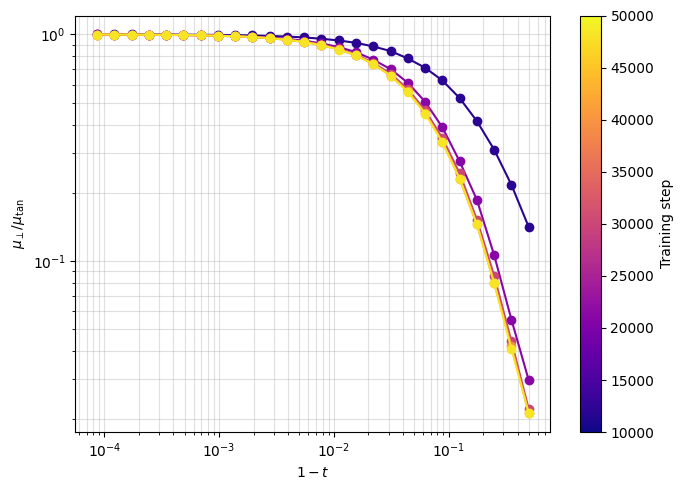

In [7]:
plt.close('all')

fig, ax = plt.subplots(figsize=(7, 5))

for color, step in zip(colors, steps_sorted):
    mp, mt = checkpoint_results[step]
    ax.loglog(
        one_minus_t,
        mp / mt,
        "o-",
        color=color,
        label=f"step {step:,}",
    )

ax.set_xlabel(r"$1-t$")
ax.set_ylabel(r"$\mu_\perp / \mu_\mathrm{tan}$")
ax.grid(True, which="both", alpha=0.4)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=steps_sorted[0], vmax=steps_sorted[-1]),
)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Training step")
plt.tight_layout()

plt.show()


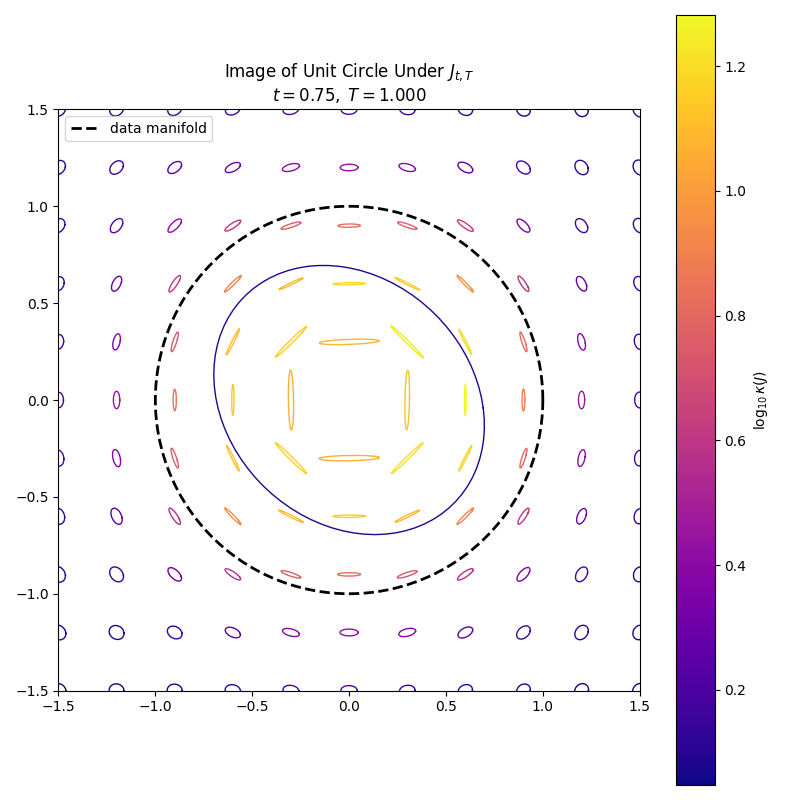

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# ============================================================
# Dynamical ellipses coloured by condition number
# ============================================================

t = 0.75
T = 0.99999

xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5

grid_size = 11
ellipse_scale = 0.05
nsteps = 200

fig, ax = plt.subplots(figsize=(8, 8))

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

# ------------------------------------------------------------
# Unit circle
# ------------------------------------------------------------

theta = np.linspace(0, 2*np.pi, 80)

circle = np.stack(
    [
        np.cos(theta),
        np.sin(theta),
    ],
    axis=0,
)

circle_torch = torch.tensor(
    circle,
    dtype=torch.float32,
    device=device,
)

# ------------------------------------------------------------
# First pass:
# compute condition numbers
# ------------------------------------------------------------

entries = []

for x1 in xs:
    for x2 in ys:

        x = torch.tensor(
            [x1, x2],
            dtype=torch.float32,
            device=device,
        )

        try:

            _, J_batch = integrate_batched(
                x.unsqueeze(0),
                t,
                T,
                nsteps=nsteps,
            )
            J = J_batch[0].cpu()

            sv = torch.linalg.svdvals(J)

            cond = (
                sv.max() /
                sv.min().clamp(min=1e-8)
            ).item()

            entries.append(
                (
                    x1,
                    x2,
                    J.detach().cpu(),
                    cond,
                )
            )

        except Exception as e:
            print(f"({x1:.2f}, {x2:.2f}) failed: {e}")

# ------------------------------------------------------------
# Colour map
# ------------------------------------------------------------

if not entries:
    raise RuntimeError("No grid points succeeded — check printed errors above.")

log_conds = np.log10(
    [e[3] for e in entries]
)

norm = Normalize(
    vmin=log_conds.min(),
    vmax=log_conds.max(),
)

cmap = cm.plasma

# ------------------------------------------------------------
# Draw ellipses
# ------------------------------------------------------------

for x1, x2, J_cpu, cond in entries:

    ellipse = (
        J_cpu.numpy()
        @ circle
    )

    ellipse *= ellipse_scale

    colour = cmap(
        norm(np.log10(cond))
    )

    ax.plot(
        x1 + ellipse[0],
        x2 + ellipse[1],
        color=colour,
        linewidth=1.0,
    )

# ------------------------------------------------------------
# Draw data manifold
# ------------------------------------------------------------

phi = np.linspace(
    0,
    2*np.pi,
    500,
)

ax.plot(
    np.cos(phi),
    np.sin(phi),
    "k--",
    linewidth=2,
    label="data manifold",
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

sm = cm.ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
)

cbar.set_label(
    r"$\log_{10}\kappa(J)$"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

ax.set_aspect("equal")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(
    rf"Image of Unit Circle Under $J_{{t,T}}$"
    "\n"
    rf"$t={t:.2f},\;T={T:.3f}$"
)

ax.legend()

plt.tight_layout()
plt.show()

# Circle R 

In [25]:
def eigh2x2(G):
    """
    Analytic eigendecomposition of a batch of
    symmetric 2x2 matrices.

    Input:
        G : (B,2,2)

    Returns:
        eigvals : (B,2) ascending order
        eigvecs : (B,2,2)
                  eigvecs[:,:,0] = e_min
                  eigvecs[:,:,1] = e_max
    """

    a = G[:, 0, 0]
    b = G[:, 0, 1]
    d = G[:, 1, 1]

    trace = a + d

    delta = torch.sqrt(
        (a - d) ** 2 + 4 * b ** 2 + 1e-30
    )

    lam_max = 0.5 * (trace + delta)
    lam_min = 0.5 * (trace - delta)

    #
    # eigenvector for lam_max
    #
    vx = b
    vy = lam_max - a

    norm = torch.sqrt(
        vx**2 + vy**2 + 1e-30
    )

    vx = vx / norm
    vy = vy / norm

    e_max = torch.stack(
        [vx, vy],
        dim=1,
    )

    #
    # perpendicular vector
    #
    e_min = torch.stack(
        [-vy, vx],
        dim=1,
    )

    eigvals = torch.stack(
        [lam_min, lam_max],
        dim=1,
    )

    eigvecs = torch.stack(
        [e_min, e_max],
        dim=2,
    )

    return eigvals, eigvecs

[0.0, 0.0625, 0.125, 0.1875, 0.25, 0.3125, 0.375, 0.4375, 0.5, 0.5625, 0.625, 0.6875, 0.75, 0.8125, 0.875, 0.9375]
t=0.000
Amax=0.1977 Amin=0.8023 sum=1.0000
t=0.062
Amax=0.1803 Amin=0.8197 sum=1.0000
t=0.125
Amax=0.1768 Amin=0.8232 sum=1.0000
t=0.188
Amax=0.2446 Amin=0.7554 sum=1.0000
t=0.250
Amax=0.2294 Amin=0.7706 sum=1.0000
t=0.312
Amax=0.2345 Amin=0.7655 sum=1.0000
t=0.375
Amax=0.2412 Amin=0.7588 sum=1.0000
t=0.438
Amax=0.1565 Amin=0.8435 sum=1.0000
t=0.500
Amax=0.0925 Amin=0.9075 sum=1.0000
t=0.562
Amax=0.0726 Amin=0.9274 sum=1.0000
t=0.625
Amax=0.0393 Amin=0.9607 sum=1.0000
t=0.688
Amax=0.0336 Amin=0.9664 sum=1.0000
t=0.750
Amax=0.0284 Amin=0.9716 sum=1.0000
t=0.812
Amax=0.0254 Amin=0.9746 sum=1.0000
t=0.875
Amax=0.0208 Amin=0.9792 sum=1.0000
t=0.938
Amax=0.0355 Amin=0.9645 sum=1.0000


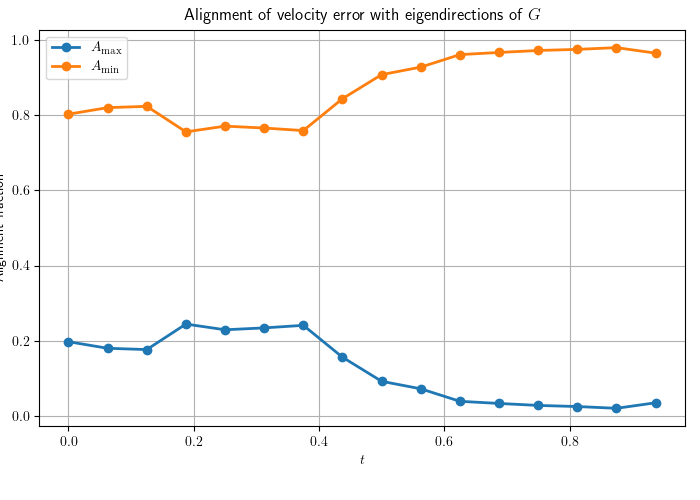

In [27]:
# ============================================================
# Alignment computation using batched Jacobian integration
# ============================================================

@torch.no_grad()
def average_alignment(
    t,
    T,
    nsamples=512,
    sigma=1.0,
    d=2,
):

    # --------------------------------------------------------
    # Sample FM points
    # --------------------------------------------------------

    theta = 2 * np.pi * torch.rand(
        nsamples,
        device=device,
    )

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=-1,
    )

    eps = torch.randn(
        nsamples,
        2,
        device=device,
    )

    x = t * z + (1 - t) * eps

    # --------------------------------------------------------
    # Exact velocity
    # --------------------------------------------------------

    v_true = true_velocity(
        x,
        t,
        sigma=sigma,
        d=d,
    )

    # --------------------------------------------------------
    # Learned velocity
    # --------------------------------------------------------

    tt = torch.full(
        (nsamples, 1),
        t,
        device=device,
    )

    v_hat = net(x, tt)

    delta_a = v_true - v_hat

    delta_norm_sq = torch.sum(
        delta_a**2,
        dim=-1,
    )

    mask = delta_norm_sq > 1e-12

    x = x[mask]
    delta_a = delta_a[mask]
    delta_norm_sq = delta_norm_sq[mask]

    if len(x) == 0:
        return np.nan, np.nan

    # --------------------------------------------------------
    # Batched Jacobian integration
    # --------------------------------------------------------

    _, J = integrate_batched(
        x,
        t,
        T,
        nsteps=200,
    )

    # --------------------------------------------------------
    # G = J^T J
    # --------------------------------------------------------

    G = torch.bmm(
        J.transpose(1, 2),
        J,
    )

    # --------------------------------------------------------
    # Batched eigendecomposition
    # --------------------------------------------------------

    eigvals, eigvecs = eigh2x2(G)

    e_min = eigvecs[:, :, 0]
    e_max = eigvecs[:, :, 1]

    # --------------------------------------------------------
    # Alignment fractions
    # --------------------------------------------------------

    proj_min = torch.sum(
        delta_a * e_min,
        dim=-1,
    )

    proj_max = torch.sum(
        delta_a * e_max,
        dim=-1,
    )

    A_min = (
        proj_min**2
        / delta_norm_sq
    )

    A_max = (
        proj_max**2
        / delta_norm_sq
    )

    return (
        A_max.mean().item(),
        A_min.mean().item(),
    )


# ============================================================
# Sweep times
# ============================================================

T = 0.999

k = 4


ts = [i*2**(-k) for i in range(2**k)]
print(ts)

Amaxs = []
Amins = []

for t in ts:

    print(f"t={t:.3f}")

    Amax, Amin = average_alignment(
        t,
        T,
        nsamples=1024,
    )

    Amaxs.append(Amax)
    Amins.append(Amin)

    print(
        f"Amax={Amax:.4f} "
        f"Amin={Amin:.4f} "
        f"sum={Amax+Amin:.4f}"
    )

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    np.array(ts),
    Amaxs,
    "o-",
    linewidth=2,
    label=r"$A_{\max}$",
)

plt.plot(
    np.array(ts),
    Amins,
    "o-",
    linewidth=2,
    label=r"$A_{\min}$",
)

plt.xlabel(r"$t$")
plt.ylabel("Alignment fraction")

plt.title(
    r"Alignment of velocity error with eigendirections of $G$"
)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import iv



def true_velocity(x, t, sigma=1.0, d=2):
    """
    x : (..., d) numpy array or torch tensor
    returns velocity of same shape
    """

    if torch.is_tensor(x):
        x_np = x.detach().cpu().numpy()
    else:
        x_np = x

    r = np.linalg.norm(x_np, axis=-1, keepdims=True)

    denom = (1 - t)**2 + t**2 * sigma**2 / d

    z = t * r / denom

    nu1 = (d + 1) / 2
    nu0 = (d - 1) / 2

    ratio = iv(nu1, z) / (iv(nu0, z) + 1e-12)

    alpha = (
        (t * sigma**2 / d - (1 - t)) / denom
        + (1 - t) / denom * ratio / (r + 1e-12)
    )

    v = alpha * x_np

    if torch.is_tensor(x):
        return torch.tensor(
            v,
            dtype=x.dtype,
            device=x.device,
        )

    return v


# ============================================================
# Average R over many FM samples
# ============================================================

@torch.no_grad()
def average_R(
    t,
    T,
    nsamples=1024,
    sigma=1.0,
    d=2,
):

    # --------------------------------------------------------
    # Sample FM states
    # --------------------------------------------------------

    theta = 2 * np.pi * torch.rand(
        nsamples,
        device=device,
    )

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=1,
    )

    eps = torch.randn(
        nsamples,
        2,
        device=device,
    )

    x = t * z + (1 - t) * eps

    # --------------------------------------------------------
    # Exact velocity
    # --------------------------------------------------------

    v_true = true_velocity(
        x,
        t,
        sigma=sigma,
        d=d,
    )

    # --------------------------------------------------------
    # Learned velocity
    # --------------------------------------------------------

    tt = torch.full(
        (nsamples, 1),
        t,
        device=device,
    )

    v_hat = net(x, tt)

    delta_a = v_true - v_hat

    delta_norm_sq = torch.sum(
        delta_a**2,
        dim=1,
    )

    mask = delta_norm_sq > 1e-12

    x = x[mask]
    delta_a = delta_a[mask]
    delta_norm_sq = delta_norm_sq[mask]

    if len(x) == 0:
        return np.nan

    # --------------------------------------------------------
    # Jacobian flow
    # --------------------------------------------------------

    _, J = integrate_batched(
        x,
        t,
        T,
        nsteps=200,
    )

    # --------------------------------------------------------
    # G = J^T J
    # --------------------------------------------------------

    G = torch.bmm(
        J.transpose(1, 2),
        J,
    )

    eigvals, _ = eigh2x2(G)

    lam_max = eigvals[:, 1]

    # --------------------------------------------------------
    # numerator = δa^T G δa
    # --------------------------------------------------------

    G_delta = torch.bmm(
        G,
        delta_a.unsqueeze(-1),
    ).squeeze(-1)

    numerator = torch.sum(
        delta_a * G_delta,
        dim=1,
    )

    denominator = (
        lam_max * delta_norm_sq
        + 1e-12
    )

    R = numerator / denominator

    return R.mean().item()


# ============================================================
# Sweep times
# ============================================================

T = 0.999
k = 4


ts = [i*2**(-k) for i in range(2**k)]
print(ts)

Rs = []

for t in ts:

    R = average_R(
        t,
        T,
        nsamples=2048,
    )

    Rs.append(R)

    print(
        f"t={t:.6f}   R={R:.4f}"
    )

[0.0, 0.0625, 0.125, 0.1875, 0.25, 0.3125, 0.375, 0.4375, 0.5, 0.5625, 0.625, 0.6875, 0.75, 0.8125, 0.875, 0.9375]


NameError: name 'eigh2x2' is not defined

In [41]:
k = 5


ts = [i*2**(-k) for i in range(2**k)]
print(len(Rs))

32


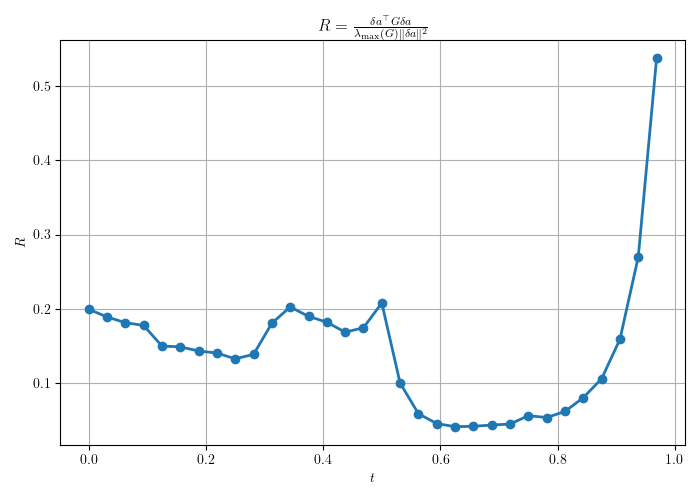

In [45]:
# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    np.array(ts),
    Rs,
    "o-",
    linewidth=2,
)

plt.xlabel(r"$t$")
plt.ylabel(r"$R$")

plt.title(
    r"$R=\frac{\delta a^\top G \delta a}"
    r"{\lambda_{\max}(G)\|\delta a\|^2}$"
)

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def average_eigval_ratio(
    t,
    T,
    nsamples=1024,
):
    theta = 2 * np.pi * torch.rand(nsamples, device=device)
    z = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
    eps = torch.randn(nsamples, 2, device=device)
    x = t * z + (1 - t) * eps

    _, J = integrate_batched(x, t, T, nsteps=200)

    G = torch.bmm(J.transpose(1, 2), J)

    eigvals, _ = eigh2x2(G)

    lam_min = eigvals[:, 0]
    lam_max = eigvals[:, 1]

    ratio = lam_min / (lam_max + 1e-12)

    return ratio.mean().item()


# ============================================================
# Sweep (reuse ts from cell 12)
# ============================================================

T = 0.999
ratios = []

for t in ts:
    r = average_eigval_ratio(t, T, nsamples=1024)
    ratios.append(r)
    print(f"t={t:.6f}   λ_min/λ_max={r:.4f}")

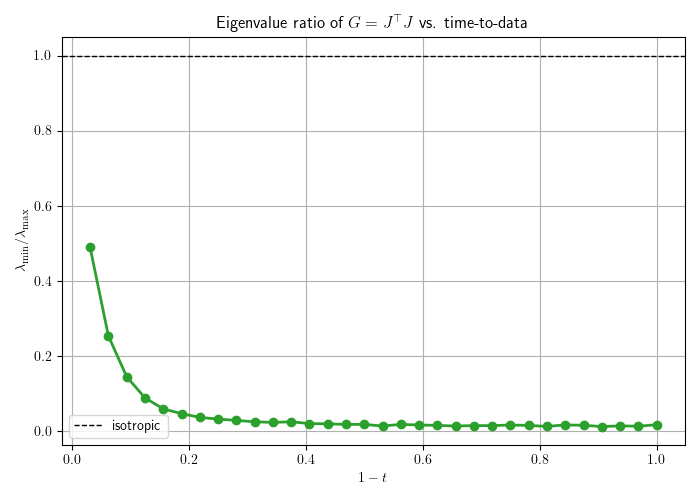

In [49]:
# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    1 - np.array(ts),
    ratios,
    "o-",
    linewidth=2,
    color="C2",
)

plt.axhline(1.0, color="k", linestyle="--", linewidth=1, label="isotropic")

plt.xlabel(r"$1 - t$")
plt.ylabel(r"$\lambda_{\min} / \lambda_{\max}$")
plt.title(r"Eigenvalue ratio of $G = J^\top J$ vs. time-to-data")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:

import numpy as np

xs = 1 - np.array(ts)
order = np.argsort(xs)
area = np.trapezoid(np.array(Rs)[order], xs[order])
print(f"Area under R curve: {area:.6f}")


Area under R curve: 0.132756


# Big test

In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment


# ============================================================
# Wasserstein-1 estimator
# ============================================================

def estimate_w1(X, Y):

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()

    diff = X[:, None, :] - Y[None, :, :]
    C = np.linalg.norm(diff, axis=-1)

    row, col = linear_sum_assignment(C)

    return C[row, col].mean()


# ============================================================
# analytic eigvals of symmetric 2x2 matrix
# ============================================================

def eigvals2x2(G):

    a = G[:, 0, 0]
    b = G[:, 0, 1]
    d = G[:, 1, 1]

    tr = a + d

    delta = torch.sqrt(
        (a - d) ** 2
        + 4 * b ** 2
        + 1e-30
    )

    lam_max = 0.5 * (tr + delta)
    lam_min = 0.5 * (tr - delta)

    return lam_min, lam_max


# ============================================================
# estimate E and E_OSL
# ============================================================

@torch.no_grad()
def estimate_metric_quantities(
    T=0.999,
    Nt=64,
    Nsamples=1024,
):

    ts = np.linspace(
        0.0,
        T,
        Nt,
    )

    dt = ts[1] - ts[0]

    E_metric = 0.0
    E_osl = 0.0

    for t in ts:

        theta = (
            2
            * np.pi
            * torch.rand(
                Nsamples,
                device=device,
            )
        )

        z = torch.stack(
            [
                torch.cos(theta),
                torch.sin(theta),
            ],
            dim=1,
        )

        eps = torch.randn(
            Nsamples,
            2,
            device=device,
        )

        x = (
            t * z
            + (1 - t) * eps
        )

        v_true = true_velocity(
            x,
            t,
        )

        tt = torch.full(
            (Nsamples, 1),
            t,
            device=device,
        )

        v_hat = net(x, tt)

        delta_a = (
            v_true
            - v_hat
        )

        _, J = integrate_batched(
            x,
            t,
            T,
            nsteps=200,
        )

        G = torch.bmm(
            J.transpose(1, 2),
            J,
        )

        lam_min, lam_max = eigvals2x2(G)

        G_delta = torch.bmm(
            G,
            delta_a.unsqueeze(-1),
        ).squeeze(-1)

        metric_integrand = torch.sqrt(
            torch.sum(
                delta_a * G_delta,
                dim=1,
            ).clamp(min=0)
        )

        osl_integrand = (
            torch.sqrt(
                lam_max.clamp(min=0)
            )
            * torch.norm(
                delta_a,
                dim=1,
            )
        )

        E_metric += (
            metric_integrand.mean().item()
            * dt
        )

        E_osl += (
            osl_integrand.mean().item()
            * dt
        )

    return E_metric, E_osl


# ============================================================
# estimate W1
# ============================================================

@torch.no_grad()
def estimate_terminal_w1(
    T=0.999,
    Nsamples=1024,
):

    x0 = torch.randn(
        Nsamples,
        2,
        device=device,
    )

    #
    # learned flow
    #

    x_hat, _ = integrate_batched(
        x0,
        0.0,
        T,
        nsteps=1000,
    )

    #
    # exact FM terminal samples
    #

    theta = (
        2
        * np.pi
        * torch.rand(
            Nsamples,
            device=device,
        )
    )

    z = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=1,
    )

    eps = torch.randn(
        Nsamples,
        2,
        device=device,
    )

    x_true = (
        T * z
        + (1 - T) * eps
    )

    return estimate_w1(
        x_true,
        x_hat,
    )


# ============================================================
# checkpoints
# ============================================================

import glob
checkpoint_paths = sorted(glob.glob(os.path.join(CKPT_DIR, "step_*.pt")))

metric_vals = []
osl_vals = []
w1_vals = []

for ckpt in checkpoint_paths:

    print()
    print("loading", ckpt)

    net.load_state_dict(
        torch.load(
            ckpt,
            map_location=device,
        )
    )

    E_metric, E_osl = (
        estimate_metric_quantities(
            T=0.999,
            Nt=64,
            Nsamples=1024,
        )
    )

    W = estimate_terminal_w1(
        T=0.999,
        Nsamples=1024,
    )

    metric_vals.append(
        E_metric
    )

    osl_vals.append(
        E_osl
    )

    w1_vals.append(
        W
    )

    print(
        f"E={E_metric:.5f}"
    )
    print(
        f"E_OSL={E_osl:.5f}"
    )
    print(
        f"W1={W:.5f}"
    )


loading checkpoints/step_005000.pt
E=0.18509
E_OSL=0.44691
W1=0.12160

loading checkpoints/step_010000.pt
E=0.15616
E_OSL=0.55593
W1=0.09752

loading checkpoints/step_015000.pt
E=0.14398
E_OSL=0.55013
W1=0.06242

loading checkpoints/step_020000.pt
E=0.13339
E_OSL=0.53895
W1=0.09793

loading checkpoints/step_025000.pt
E=0.12376
E_OSL=0.53096
W1=0.07547

loading checkpoints/step_030000.pt
E=0.12058
E_OSL=0.53478
W1=0.05948

loading checkpoints/step_035000.pt
E=0.11780
E_OSL=0.52755
W1=0.07121

loading checkpoints/step_040000.pt
E=0.11672
E_OSL=0.52443
W1=0.04754

loading checkpoints/step_045000.pt
E=0.11606
E_OSL=0.52920
W1=0.04995

loading checkpoints/step_050000.pt
E=0.11568
E_OSL=0.52449
W1=0.06462


In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the checkpoints
data = {
    'step': [5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000],
    'E': [0.18509, 0.15616, 0.14398, 0.13339, 0.12376, 0.12058, 0.11780, 0.11672, 0.11606, 0.11568],
    'E_OSL': [0.44691, 0.55593, 0.55013, 0.53895, 0.53096, 0.53478, 0.52755, 0.52443, 0.52920, 0.52449],
    'W1': [0.12160, 0.09752, 0.06242, 0.09793, 0.07547, 0.05948, 0.07121, 0.04754, 0.04995, 0.06462]
}

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Scatter plot for E
scatter1 = ax1.scatter(data['W1'], data['E'], color='blue', s=100, alpha=0.7, label='E')
ax1.set_xlabel('W1', fontsize=12)
ax1.set_ylabel('E', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for E_OSL
ax2 = ax1.twinx()
scatter2 = ax2.scatter(data['W1'], data['E_OSL'], color='red', s=100, alpha=0.7, label='E_OSL')
ax2.set_ylabel('E_OSL', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add step numbers as labels for each point
for i, step in enumerate(data['step']):
    ax1.annotate(f'{step}', (data['W1'][i], data['E'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax2.annotate(f'{step}', (data['W1'][i], data['E_OSL'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Add title and grid
plt.title('Scatter Plot of E and E_OSL vs W1', fontsize=14, pad=20)
ax1.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()

# Print the data in a formatted table for reference
print("\nData Table:")
print("-" * 60)
print(f"{'Step':<10} {'W1':<10} {'E':<10} {'E_OSL':<10}")
print("-" * 60)
for i in range(len(data['step'])):
    print(f"{data['step'][i]:<10} {data['W1'][i]:<10.5f} {data['E'][i]:<10.5f} {data['E_OSL'][i]:<10.5f}")

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x16495a340> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [53]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Enable the system LaTeX engine
mpl.rcParams['text.usetex'] = True

# ============================================================
# scatter: theorem quantity
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    metric_vals,
    w1_vals,
    s=60,
)

plt.xlabel(r"$\mathcal E$")
plt.ylabel(r"$W_1$")

plt.title(
    r"$W_1$ vs metric bound"
)

plt.grid(True)

plt.tight_layout()
plt.show()

/var/folders/_g/82fk0b191zd7nd1w43sw45ww0000gn/T/ipykernel_71558/572366460.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 5))


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x16495a340> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [52]:
# ============================================================
# scatter: OSL quantity
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    osl_vals,
    w1_vals,
    s=60,
)

plt.xlabel(
    r"$\mathcal E_{\rm OSL}$"
)
plt.ylabel(
    r"$W_1$"
)

plt.title(
    r"$W_1$ vs OSL bound"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# compare the two bounds directly
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    osl_vals,
    metric_vals,
    s=60,
)

mx = max(
    max(osl_vals),
    max(metric_vals),
)

plt.plot(
    [0, mx],
    [0, mx],
    "--",
)

plt.xlabel(
    r"$\mathcal E_{\rm OSL}$"
)
plt.ylabel(
    r"$\mathcal E$"
)

plt.title(
    "Metric bound vs OSL bound"
)

plt.grid(True)

plt.tight_layout()
plt.show()


print()
print(
    "Average improvement factor:",
    np.mean(
        np.array(osl_vals)
        /
        np.array(metric_vals)
    ),
)

KeyboardInterrupt: 

In [15]:

steps = [int(os.path.basename(p).replace("step_", "").replace(".pt", "")) for p in checkpoint_paths]

print(f"{'Step':>8}  {'E':>10}  {'E_OSL':>10}  {'W1':>10}")
print("-" * 46)
for step, E, E_osl, W in zip(steps, metric_vals, osl_vals, w1_vals):
    print(f"{step:>8d}  {E:>10.5f}  {E_osl:>10.5f}  {W:>10.5f}")


    Step           E       E_OSL          W1
----------------------------------------------
    5000     0.16120     0.23127     0.24395
   10000     0.18226     0.43906     0.10945
   15000     0.17750     0.49848     0.09008
   20000     0.17190     0.51041     0.10349
   25000     0.16615     0.51242     0.08775
   30000     0.16293     0.51896     0.11417
   35000     0.16161     0.51769     0.08274
   40000     0.16100     0.51930     0.09829
   45000     0.16123     0.52265     0.10651
   50000     0.15958     0.51962     0.08378


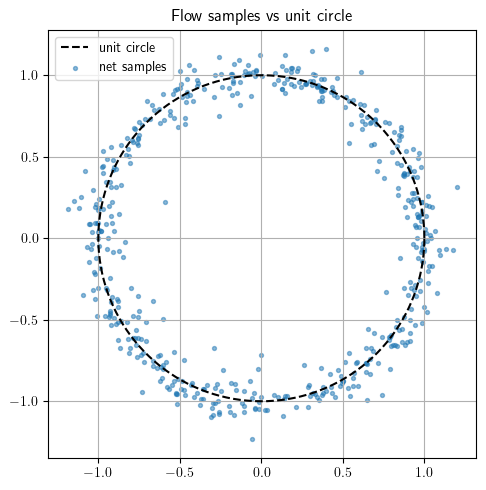

In [16]:

@torch.no_grad()
def generate_samples(nsamples=512, T=0.999):
    x0 = torch.randn(nsamples, 2, device=device)
    x_T, _ = integrate_batched(x0, 0.0, T, nsteps=500)
    return x_T.cpu().numpy()

samples = generate_samples()

theta = np.linspace(0, 2 * np.pi, 300)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(circle_x, circle_y, "k--", linewidth=1.5, label="unit circle")
ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.5, label="net samples")
ax.set_aspect("equal")
ax.legend()
ax.grid(True)
ax.set_title("Flow samples vs unit circle")
plt.tight_layout()
plt.show()
